# Lab Exercise [30 Marks]

### <font color='red'>Deadline: 6<sup>th</sup> June 2026 (Saturday), 2.00pm.</font>

## Submission Instructions

- Download and rename this notebook according to your tutorial session and group number, e.g.: `LabEx_TTXL_GXX.ipynb`.
- Fill in all group members' details in the following Markdown cell.
- Fill in every group member's contribution in percentage, with the total 100%. All the members MUST AGREE to the percentages before submission. For example, the group members agree to give 0% contribution to the sleeping group member. 
- Not all group members in the same group will get the same mark. Your mark is depending on your contribution to the group work.
- Complete all the questions. Fill in your ANSWERS IN THIS NOTEBOOK.
- Submit this <b> .ipynb file </b> according to your registered group  in EbWise . Name your submission file as `LabEx_TTXL_GXX.ipynb`.
- Ensure that your notebook runs without errors on the examiner’s machine using the provided data file. Any cell that does not execute successfully in this environment will receive zero marks.


## Penalties
- For submission that does not conform to <i> Submission Instructions </i>, <b> 5 marks will be deducted </b>. 
- For submission <i> after the Deadline </i>, late submission penalty is applied with a deduction of <b> 1 mark per minute </b>. 

#### Group_3

**Tutorial section: TT2L**


| | Student ID     | Student Name                | Contribution | 
|--:|:-------------|:----------------------------|-------------:|
| 1 | 1211110507   | LAW ZHEN CHENG              | 25%          | 
| 2 | 253UC256L3   | TAN KHAI YU                 | 25%          | 
| 3 | 243UC246W3   | YAP JIET IN                 | 25%          | 
| 4 | 253UC256TQ   | YONG SIN YING               | 25%          |


### Import Libraries

In [1]:
import pandas as pd                               # For dataframes
import matplotlib.pyplot as plt                   # For plotting data
import seaborn as sns                             # For plotting data
import numpy as np
import os

### Load Data
Data can be downloaded from [WHO](https://www.who.int/data).


In [2]:
# === Load Data ===
Drive_path = ""
DATA_FILE = "LifeExpectancy_cleaned.csv"
assert os.path.exists(Drive_path + DATA_FILE), f"File not found: {DATA_FILE}. Please place the data file in this directory."

df = pd.read_csv(Drive_path + DATA_FILE)
print(df.shape)
display(df.head())

(16280, 7)


,WHORegionCode,WHORegion,CountryCode,Country,Year,Sex,Life expectancy (years)
0,EMR,Eastern Mediterranean,AFG,Afghanistan,2000,Female,54.43
1,EMR,Eastern Mediterranean,AFG,Afghanistan,2000,Female,13.21
2,EMR,Eastern Mediterranean,AFG,Afghanistan,2000,Male,53.25
3,EMR,Eastern Mediterranean,AFG,Afghanistan,2000,Male,13.07
4,EMR,Eastern Mediterranean,AFG,Afghanistan,2001,Female,54.57


### Part 1: Data Preparation – Separating Life Expectancy Indicators [5m]

Prepare the dataset for analysis by separating the combined life expectancy variable into two meaningful **indicators**:
- at birth
- at age 60
  
In the provided dataset, both life expectancy at birth and life expectancy at age 60 are stored in a single column named: `Life expectancy (years)`.
Before any exploratory analysis, this column must be separated into two distinct variables.


Assumption:
- Life expectancy at birth is greater than or equal to 35 years
- Life expectancy at age 60 is smaller than 35 years


Tasks:
- Create a new column called `Life expectancy at birth`.
- Create a new column called `Life expectancy at age 60`.
- Populate each new column using the assumptions above.
- Delete the original `Life expectancy (years)`
- Save the data file as `LifeExpectancy_separated.csv`

Expected output:
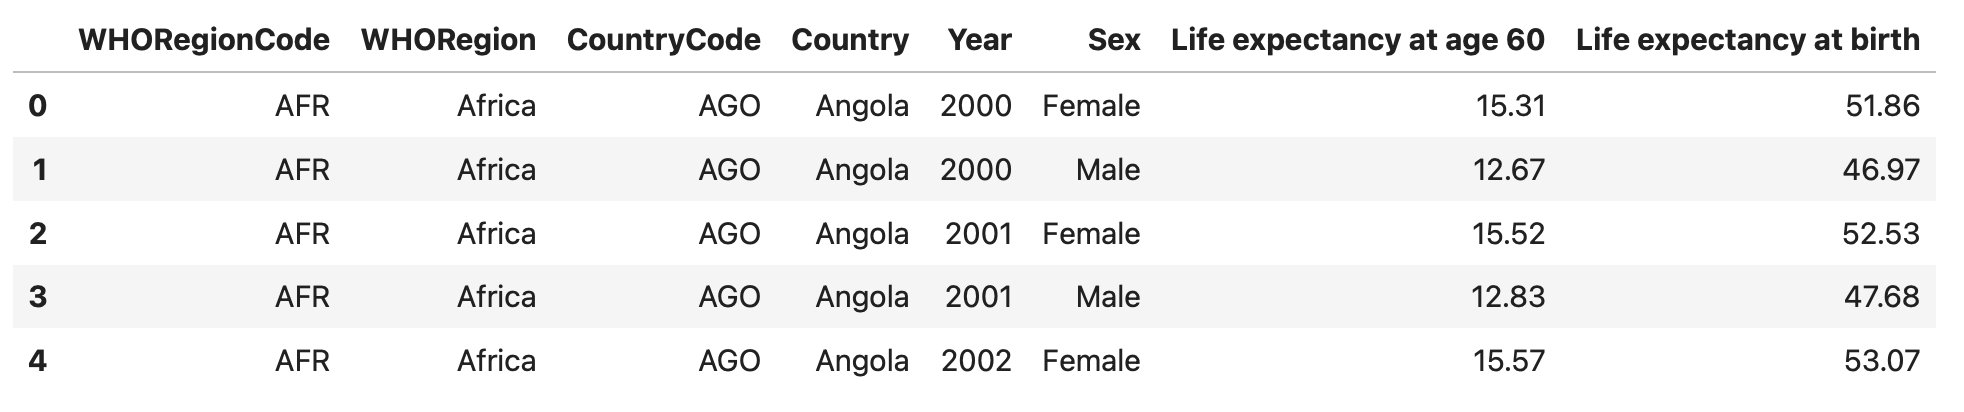

For Part 1, I split the original `Life expectancy (years)` column into two separate indicators using the rule given in the question. Values greater than or equal to 35 years are treated as life expectancy at birth, while values below 35 years are treated as life expectancy at age 60. After creating the two indicator columns, I removed the original combined column and grouped the records so that each country-year-sex combination appears once with both life expectancy values in the same row.

In [3]:
# === Part 1: Data Preparation – Separating Life Expectancy Indicators ===

# Make a working copy of the original dataframe
df_part1 = df.copy()

# Create the two new indicator columns based on the given assumptions
df_part1["Life expectancy at birth"] = df_part1["Life expectancy (years)"].where(
    df_part1["Life expectancy (years)"] >= 35
)

df_part1["Life expectancy at age 60"] = df_part1["Life expectancy (years)"].where(
    df_part1["Life expectancy (years)"] < 35
)

# Columns that uniquely identify each country-year-sex record
id_cols = ["WHORegionCode", "WHORegion", "CountryCode", "Country", "Year", "Sex"]

# Combine the birth and age-60 rows into one row per country-year-sex
df_separated = (
    df_part1
    .drop(columns=["Life expectancy (years)"])
    .groupby(id_cols, as_index=False)
    .agg({
        "Life expectancy at age 60": "max",
        "Life expectancy at birth": "max"
    })
)

# Arrange columns in the same format as the expected output
df_separated = df_separated[
    id_cols + ["Life expectancy at age 60", "Life expectancy at birth"]
]

# Sort the data to match the expected output order
df_separated = df_separated.sort_values(id_cols).reset_index(drop=True)

# Save the separated dataset
OUTPUT_FILE = "LifeExpectancy_separated.csv"
df_separated.to_csv(Drive_path + OUTPUT_FILE, index=False)

# Replace df with the prepared dataset for the later parts of the lab
df = df_separated.copy()

# Check the result
print(df.shape)
display(df.head())

(8140, 8)


,WHORegionCode,WHORegion,CountryCode,Country,Year,Sex,Life expectancy at age 60,Life expectancy at birth
0,AFR,Africa,AGO,Angola,2000,Female,15.31,51.86
1,AFR,Africa,AGO,Angola,2000,Male,12.67,46.97
2,AFR,Africa,AGO,Angola,2001,Female,15.52,52.53
3,AFR,Africa,AGO,Angola,2001,Male,12.83,47.68
4,AFR,Africa,AGO,Angola,2002,Female,15.57,53.07


### Part 2: Distribution Analysis [5m]
- Plot 2 histogram to show the distribution of life expectancy of both indicators, use `bins=30`.
- Compare their central tendencies (mean, median).
- Plot the boxplot of both indicators in a graph.
- List out all the outliers by country.

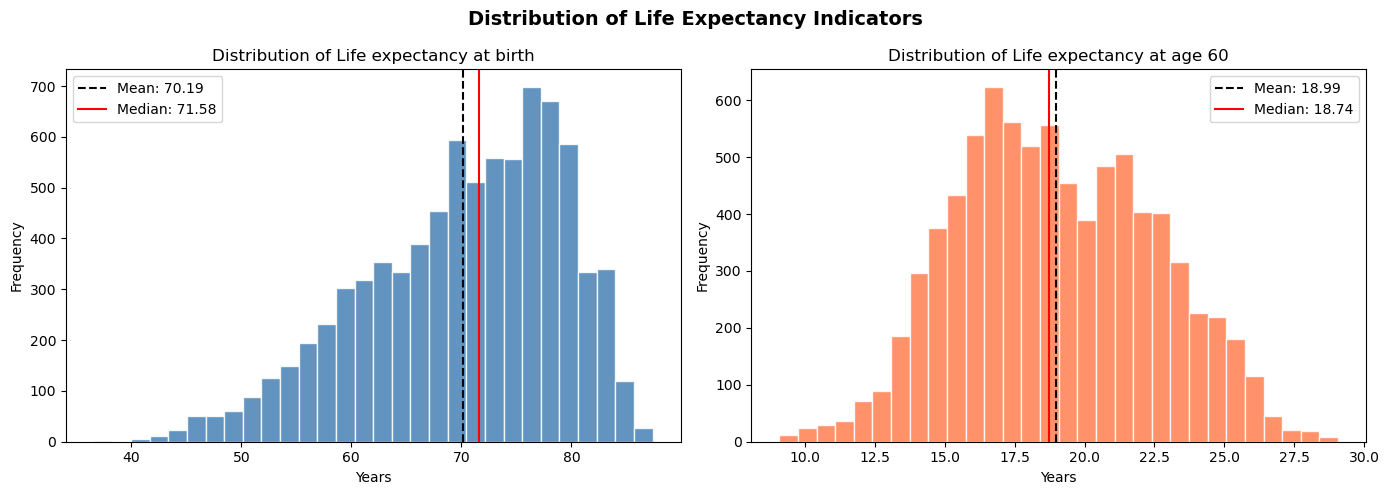

Central Tendencies:
  Life expectancy at birth: Mean = 70.19, Median = 71.58
  Life expectancy at age 60: Mean = 18.99, Median = 18.74


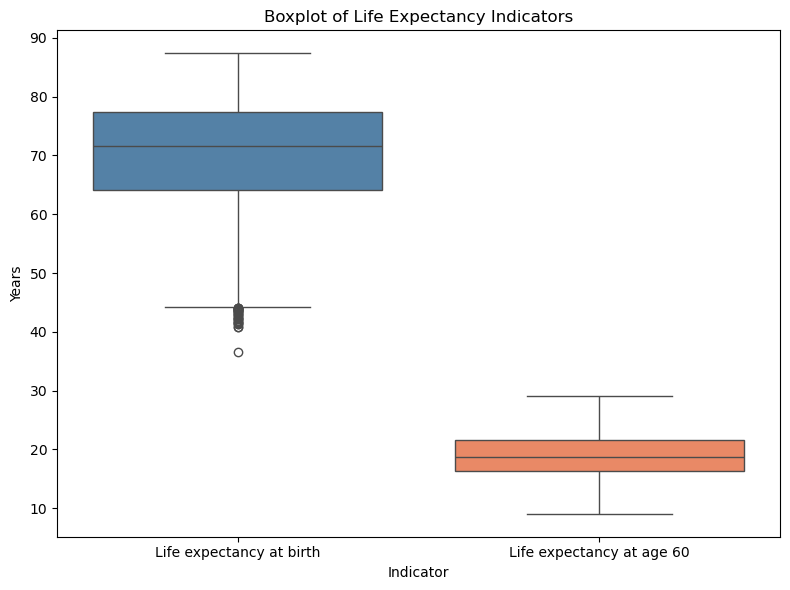


Outliers by Country:


,Indicator,Country,Year,Sex,Outlier Value
0,Life expectancy at birth,Burundi,2000,Male,41.83
1,Life expectancy at birth,Burundi,2001,Male,43.11
2,Life expectancy at birth,Central African Republic,2000,Male,43.42
3,Life expectancy at birth,Central African Republic,2001,Male,43.63
4,Life expectancy at birth,Central African Republic,2002,Male,43.87
14,Life expectancy at birth,Eswatini,2001,Male,43.22
15,Life expectancy at birth,Eswatini,2002,Male,42.24
16,Life expectancy at birth,Eswatini,2003,Female,43.83
17,Life expectancy at birth,Eswatini,2003,Male,41.40
18,Life expectancy at birth,Eswatini,2004,Female,42.95


In [8]:
# === Part 2: Distribution Analysis ===

# --- 2.1: Histograms ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color in zip(axes,
                           ['Life expectancy at birth', 'Life expectancy at age 60'],
                           ['steelblue', 'coral']):
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='red', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.2f}')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Years')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Distribution of Life Expectancy Indicators', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 2.2: Central Tendency Comparison ---
print("Central Tendencies:")
for col in ['Life expectancy at birth', 'Life expectancy at age 60']:
    print(f"  {col}: Mean = {df[col].mean():.2f}, Median = {df[col].median():.2f}")

# --- 2.3: Boxplot ---
fig, ax = plt.subplots(figsize=(8, 6))
df_melt = df[['Life expectancy at birth', 'Life expectancy at age 60']].melt(
    var_name='Indicator', value_name='Years')
sns.boxplot(data=df_melt, x='Indicator', y='Years', hue='Indicator',
            palette=['steelblue', 'coral'], legend=False, ax=ax)
ax.set_title('Boxplot of Life Expectancy Indicators')
ax.set_xlabel('Indicator')
ax.set_ylabel('Years')
plt.tight_layout()
plt.show()

# --- 2.4: Outliers by Country ---
print("\nOutliers by Country:")

all_outliers = []

for col in ['Life expectancy at birth', 'Life expectancy at age 60']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)][
        ['Country', 'Year', 'Sex', col]
    ].copy()

    outliers.insert(0, 'Indicator', col)
    outliers = outliers.rename(columns={col: 'Outlier Value'})
    all_outliers.append(outliers)

outlier_df = pd.concat(all_outliers, ignore_index=True)

if outlier_df.empty:
    print("No outliers detected.")
else:
    display(outlier_df.sort_values(['Indicator', 'Country', 'Year', 'Sex']))

### Part 3: Gender-Based Analysis [5m]

- Compute average life expectancy for both indicators by sex.
- Visualize the average life expectancy of both indicators by gender with suitable plot.
- Calculate the gender gap (Female − Male) for both indicators.
- State your observation.

------- 1. Average Life Expectancy by Sex and Indicator -------
Sex                           Female       Male
Indicator                                      
Life expectancy at age 60  20.363555  17.618211
Life expectancy at birth   72.606550  67.766467

------- 2. Calculated Gender Gap (Female - Male) -------
Sex                        Gender Gap (F - M)
Indicator                                    
Life expectancy at age 60            2.745344
Life expectancy at birth             4.840084


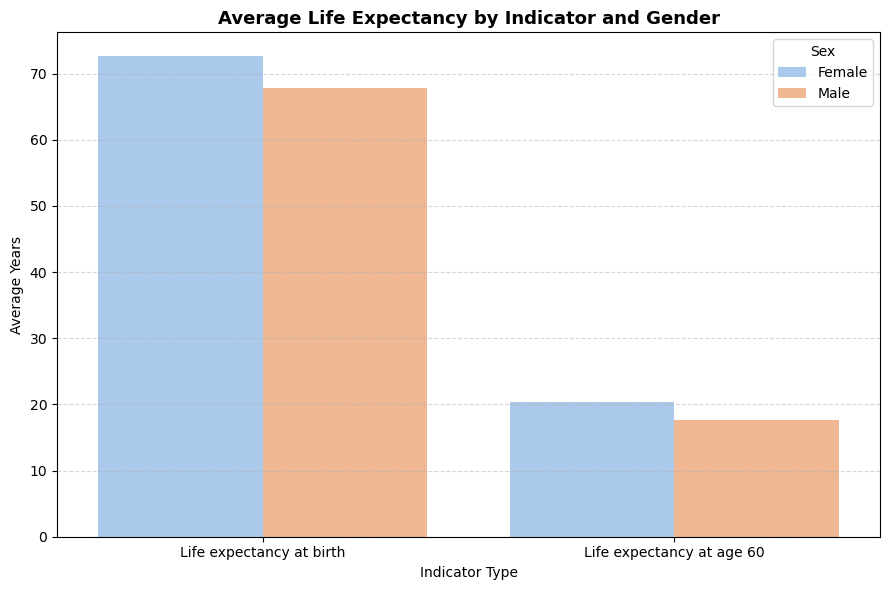

In [5]:
#Part 3: Gender-Based Analysis
df_p3 = df.copy()
life_cols = ['Life expectancy at birth', 'Life expectancy at age 60']
df_p3 = df_p3.melt(    
    id_vars=['WHORegionCode','WHORegion','CountryCode','Country','Year','Sex'],
    value_vars=life_cols,
    var_name='Indicator',
    value_name='Life Expectancy'
)
col_life = 'Life Expectancy'
col_sex  = 'Sex'

# 1. [Requirement 1]: Compute average life expectancy for both indicators by sex
gender_avg = df_p3.groupby(['Indicator', col_sex])[col_life].mean().unstack()
print("------- 1. Average Life Expectancy by Sex and Indicator -------")
print(gender_avg)

# 2. [Requirement 3]: Calculate the gender gap (Female − Male) for both indicators
fem_col = [c for c in gender_avg.columns if 'fem' in c.lower()][0]
male_col = [c for c in gender_avg.columns if 'male' in c.lower() and 'fem' not in c.lower()][0]
gender_avg['Gender Gap (F - M)'] = gender_avg[fem_col] - gender_avg[male_col]
print("\n------- 2. Calculated Gender Gap (Female - Male) -------")
print(gender_avg[['Gender Gap (F - M)']])

# 3. [Requirement 2]: Visualize the average life expectancy with a suitable plot
plt.figure(figsize=(9, 6))
sns.barplot(
    data=df_p3,
    x='Indicator',
    y=col_life,
    hue=col_sex,
    estimator=np.mean,
    errorbar=None,
    palette='pastel'
)
plt.title('Average Life Expectancy by Indicator and Gender', fontsize=13, fontweight='bold')
plt.xlabel('Indicator Type')
plt.ylabel('Average Years')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Observation:**

1. Females consistently show higher average life expectancy than males across both 
   indicators globally. For life expectancy at birth, females average approximately 
   72.6 years compared to 67.8 years for males. For life expectancy at age 60, females 
   average approximately 20.4 years vs 17.6 years for males.
   
2. The gender gap (Female − Male) is larger for life expectancy at birth than for 
   life expectancy at age 60. This suggests that while females have a survival 
   advantage throughout life, the gap narrows at older ages — likely because 
   risk factors such as occupational hazards and lifestyle differences that 
   disadvantage males are less pronounced in elderly populations.

### Part 4: Regional Comparisons [5m]
- Compute regional averages for both indicators.
- Compare WHO regions with suitable plot.
- Identify regions with the highest and lowest life expectancy for both indicators.
- State your observation.



------- 1. Regional Summary Matrix -------
Indicator              Life expectancy at age 60  Life expectancy at birth
WHORegion                                                                 
Africa                                 15.982437                 59.866291
Americas                               20.943590                 74.250508
Eastern Mediterranean                  18.818202                 70.962738
Europe                                 20.681268                 76.148132
South-East Asia                        18.864500                 70.331386
Western Pacific                        18.788543                 71.562293


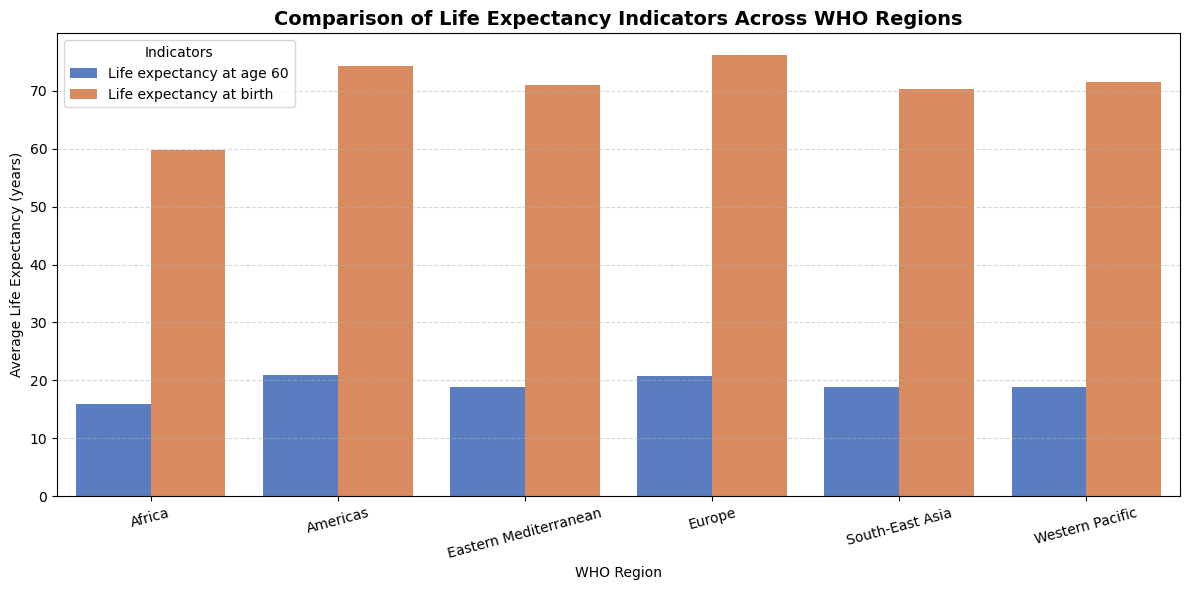


------- 2. Highest and Lowest Regions Identified -------
[Life expectancy at age 60]
 - Highest Region: Americas (20.94 years)
 - Lowest Region: Africa (15.98 years)

[Life expectancy at birth]
 - Highest Region: Europe (76.15 years)
 - Lowest Region: Africa (59.87 years)



In [6]:
#Part 4: Regional Comparisons

df_p4 = df.copy()
life_cols = ['Life expectancy at birth', 'Life expectancy at age 60']
df_p4 = df_p4.melt(
    id_vars=['WHORegionCode','WHORegion','CountryCode','Country','Year','Sex'],
    value_vars=life_cols,
    var_name='Indicator',
    value_name='Life Expectancy'
)
col_life   = 'Life Expectancy'
col_region = 'WHORegion'

# 1. Compute regional averages for both indicators
regional_avg = df_p4.groupby([col_region, 'Indicator'])[col_life].mean().reset_index()
print("------- 1. Regional Summary Matrix -------")
print(regional_avg.pivot(index=col_region, columns='Indicator', values=col_life))

# 2. Compare WHO regions with a suitable plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=regional_avg,
    x=col_region,
    y=col_life,
    hue='Indicator',
    palette='muted'
)
plt.title('Comparison of Life Expectancy Indicators Across WHO Regions', fontsize=14, fontweight='bold')
plt.xlabel('WHO Region')
plt.ylabel('Average Life Expectancy (years)')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Indicators')
plt.tight_layout()
plt.show()

# 3. Identify regions with the highest and lowest life expectancy for both indicators
print("\n------- 2. Highest and Lowest Regions Identified -------")
for ind in regional_avg['Indicator'].unique():
    sub_df = regional_avg[regional_avg['Indicator'] == ind]
    highest = sub_df.loc[sub_df[col_life].idxmax()]
    lowest = sub_df.loc[sub_df[col_life].idxmin()]
    print(f"[{ind}]")
    print(f" - Highest Region: {highest[col_region]} ({highest[col_life]:.2f} years)")
    print(f" - Lowest Region: {lowest[col_region]} ({lowest[col_life]:.2f} years)\n")

**Observation:**
1. Europe (EUR) records the highest life expectancy at birth (76.15 years), 
   while Americas (AMR) leads for life expectancy at age 60 (20.94 years). 
   This reflects Europe's strong overall population health, while the Americas' 
   advantage at age 60 suggests better elderly care and quality of life for 
   older populations.

2. Africa (AFR) records the lowest life expectancy for both indicators — 
   59.87 years at birth and 15.98 years at age 60. The gap between Africa and 
   Europe for life expectancy at birth is over 16 years (76.15 vs 59.87), 
   highlighting critical challenges in maternal health, child mortality, 
   infectious disease burden, and limited healthcare access across the region.

3. Eastern Mediterranean (EMR), South-East Asia (SEAR), and Western Pacific 
   (WPR) fall in the middle range (70–72 years at birth, 18–19 years at age 60), 
   showing comparable levels of development in healthcare infrastructure across 
   these regions.

### Part 5: Time Trends [10m]
- Plot a life expectancy trends over time for Malaysia , Indonesia and Thailand in the same plot. (2m)
- Plot regional average life expectancy trends over time: 1 for each indicator. (2m)
- Plot a regional life expectancy at birth percentage change, and identify periods of stagnation, acceleration, or decline. (6m)

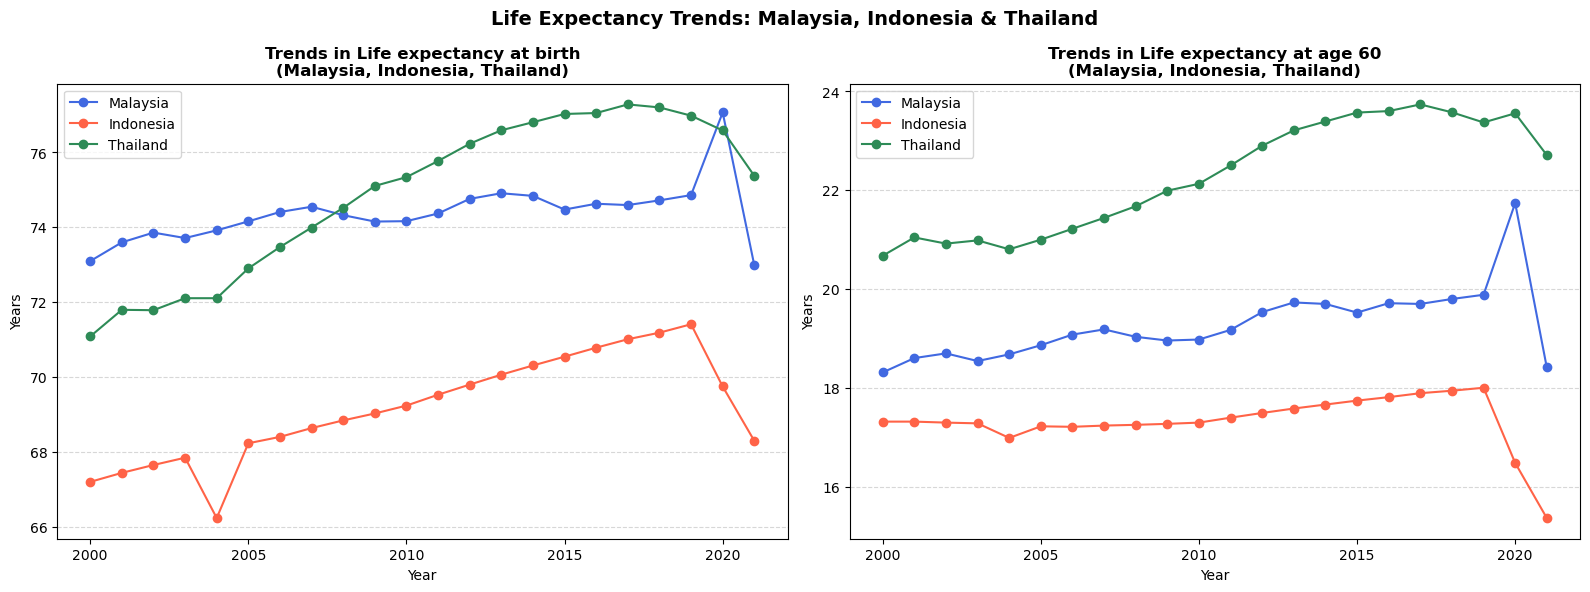

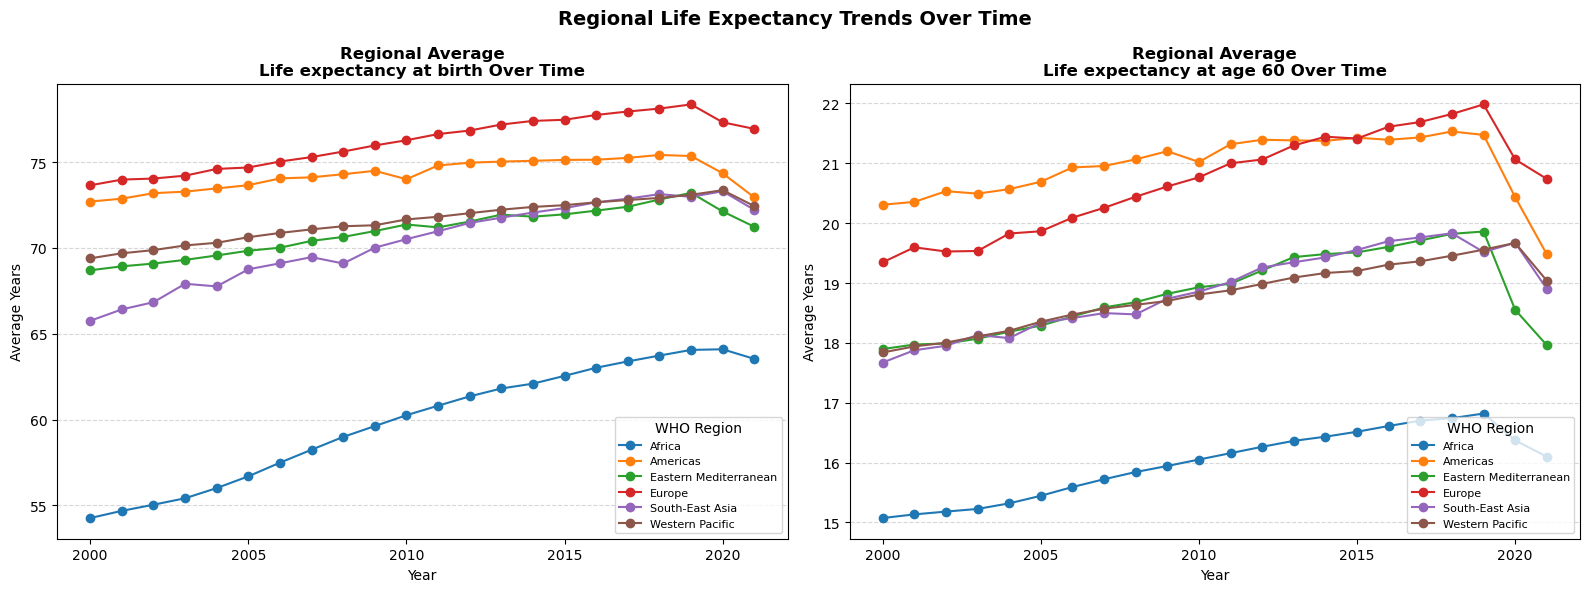

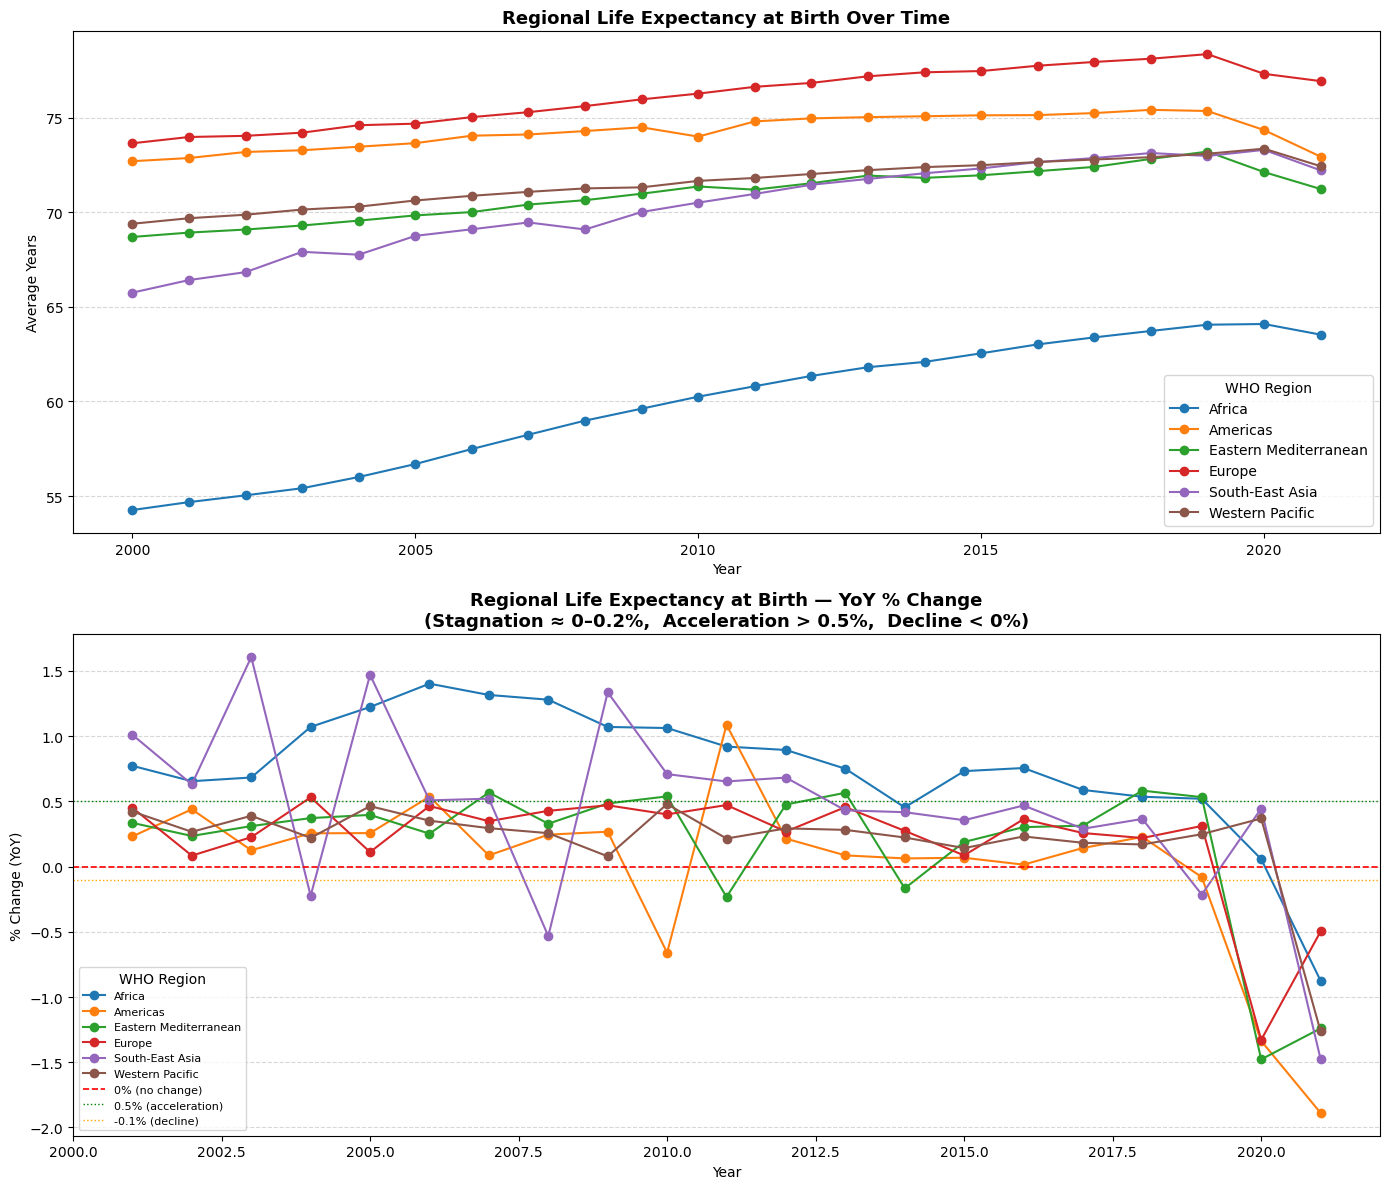


===== Period Classification per WHO Region =====

Africa:
  2001–2013 (13 yrs): Acceleration
  2014: Moderate growth
  2015–2019 (5 yrs): Acceleration
  2020: Stagnation
  2021: Decline

Americas:
  2001–2002 (2 yrs): Moderate growth
  2003: Stagnation
  2004–2005 (2 yrs): Moderate growth
  2006: Acceleration
  2007: Stagnation
  2008–2009 (2 yrs): Moderate growth
  2010: Decline
  2011: Acceleration
  2012: Moderate growth
  2013–2017 (5 yrs): Stagnation
  2018: Moderate growth
  2019–2021 (3 yrs): Decline

Eastern Mediterranean:
  2001–2006 (6 yrs): Moderate growth
  2007: Acceleration
  2008–2009 (2 yrs): Moderate growth
  2010: Acceleration
  2011: Decline
  2012: Moderate growth
  2013: Acceleration
  2014: Decline
  2015: Stagnation
  2016–2017 (2 yrs): Moderate growth
  2018–2019 (2 yrs): Acceleration
  2020–2021 (2 yrs): Decline

Europe:
  2001: Moderate growth
  2002: Stagnation
  2003: Moderate growth
  2004: Acceleration
  2005: Stagnation
  2006–2014 (9 yrs): Moderate grow

In [9]:
# === Part 5: Time Trends ===
df = pd.read_csv("LifeExpectancy_separated.csv")

# ── 5.1  Malaysia, Indonesia, Thailand trends over time ──────────────────────
df_p5 = df[df['Country'].isin(['Malaysia', 'Indonesia', 'Thailand'])].copy()

# Average across Female & Male for a combined line per country
df_p5_avg = (
    df_p5.groupby(['Country', 'Year'])[['Life expectancy at birth', 'Life expectancy at age 60']]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
indicators = ['Life expectancy at birth', 'Life expectancy at age 60']
colors = {'Malaysia': 'royalblue', 'Indonesia': 'tomato', 'Thailand': 'seagreen'}

for ax, ind in zip(axes, indicators):
    for country, color in colors.items():
        sub = df_p5_avg[df_p5_avg['Country'] == country].sort_values('Year')
        ax.plot(sub['Year'], sub[ind], marker='o', label=country, color=color)
    ax.set_title(f'Trends in {ind}\n(Malaysia, Indonesia, Thailand)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Years')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Life Expectancy Trends: Malaysia, Indonesia & Thailand', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# ── 5.2  Regional average life expectancy trends over time ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, ind in zip(axes, indicators):
    regional_trend = (
        df.groupby(['WHORegion', 'Year'])[ind]
        .mean()
        .reset_index()
    )
    for region, grp in regional_trend.groupby('WHORegion'):
        grp_sorted = grp.sort_values('Year')
        ax.plot(grp_sorted['Year'], grp_sorted[ind], marker='o', label=region)
    ax.set_title(f'Regional Average\n{ind} Over Time', fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Average Years')
    ax.legend(title='WHO Region', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Regional Life Expectancy Trends Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# ── 5.3  Regional Life Expectancy at Birth — Percentage Change ───────────────
df_birth = (
    df.groupby(['WHORegion', 'Year'])['Life expectancy at birth']
    .mean()
    .reset_index()
    .sort_values(['WHORegion', 'Year'])
)
df_birth['pct_change'] = (
    df_birth.groupby('WHORegion')['Life expectancy at birth']
    .pct_change() * 100
)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

for region, grp in df_birth.groupby('WHORegion'):
    axes[0].plot(grp['Year'], grp['Life expectancy at birth'], marker='o', label=region)
axes[0].set_title('Regional Life Expectancy at Birth Over Time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average Years')
axes[0].legend(title='WHO Region')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for region, grp in df_birth.groupby('WHORegion'):
    grp_clean = grp.dropna(subset=['pct_change'])
    axes[1].plot(grp_clean['Year'], grp_clean['pct_change'], marker='o', label=region)

axes[1].axhline(0,    color='red',    linestyle='--', linewidth=1.2, label='0% (no change)')
axes[1].axhline(0.5,  color='green',  linestyle=':',  linewidth=1.0, label='0.5% (acceleration)')
axes[1].axhline(-0.1, color='orange', linestyle=':',  linewidth=1.0, label='-0.1% (decline)')
axes[1].set_title('Regional Life Expectancy at Birth — YoY % Change\n'
                  '(Stagnation ≈ 0–0.2%,  Acceleration > 0.5%,  Decline < 0%)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% Change (YoY)')
axes[1].legend(title='WHO Region', fontsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Period classification
print("\n===== Period Classification per WHO Region =====")
for region, grp in df_birth.groupby('WHORegion'):
    grp_clean = grp.dropna(subset=['pct_change']).copy()
    grp_clean['Phase'] = grp_clean['pct_change'].apply(
        lambda x: 'Decline'         if x < 0
             else 'Stagnation'      if x < 0.2
             else 'Acceleration'    if x >= 0.5
             else 'Moderate growth'
    )
    print(f"\n{region}:")
    
    # Sort by year to ensure correct ordering
    grp_clean = grp_clean.sort_values('Year').reset_index(drop=True)
    
    # Group truly consecutive years with same phase
    consecutive_groups = []
    start_idx = 0
    for i in range(1, len(grp_clean)):
        year_gap = grp_clean.loc[i, 'Year'] - grp_clean.loc[i-1, 'Year']
        phase_changed = grp_clean.loc[i, 'Phase'] != grp_clean.loc[i-1, 'Phase']
        if year_gap > 1 or phase_changed:
            consecutive_groups.append(grp_clean.iloc[start_idx:i])
            start_idx = i
    consecutive_groups.append(grp_clean.iloc[start_idx:])
    
    # Print each consecutive group in chronological order
    for g in consecutive_groups:
        phase = g['Phase'].iloc[0]
        years = sorted(g['Year'].tolist())
        if len(years) == 1:
            print(f"  {years[0]}: {phase}")
        else:
            print(f"  {years[0]}–{years[-1]} ({len(years)} yrs): {phase}")

**Observation (5.3: Regional Life Expectancy at Birth — % Change):**

1. **Africa (AFR)** shows the most dramatic improvement, with 18 years of 
   acceleration (2001–2019), the longest acceleration period among all regions. 
   This rapid growth is likely driven by the Millennium Development Goals (MDGs), 
   expanded HIV/AIDS antiretroviral treatment, and improved maternal and child 
   healthcare programs. A brief stagnation in 2020 and decline in 2021 likely 
   reflect the impact of the COVID-19 pandemic.

2. **Western Pacific (WPR)** shows the most stable and consistent trend, with 
   16 years of moderate growth (2001–2020) and no acceleration periods, indicating 
   already-high life expectancy with little room for rapid gains. The single 
   decline in 2021 is attributable to COVID-19 disruptions.

3. **Europe (EUR)** similarly shows stable moderate growth across 15 years 
   (2001–2019), reflecting mature and well-funded healthcare systems. Only 1 year 
   of acceleration (2004) was recorded, and 2 years of decline (2020–2021) 
   coincide directly with the COVID-19 pandemic's heavy toll on European nations.

4. **South-East Asia (SEAR)** experienced strong acceleration for 10 years 
   (2001–2012), driven by rapid economic development and healthcare expansion 
   across countries like India and Indonesia, before transitioning to moderate 
   growth (2013–2020).

5. **Americas (AMR)** and **Eastern Mediterranean (EMR)** show mixed patterns 
   with multiple phase shifts between acceleration, moderate growth, stagnation, 
   and decline — suggesting uneven healthcare progress across countries within 
   these regions, influenced by political instability, economic inequality, 
   and conflict in certain member countries.

6. **COVID-19 Impact (2020–2021):** Nearly all regions recorded stagnation or 
   decline in 2020–2021, clearly reflecting the global impact of the COVID-19 
   pandemic on life expectancy at birth.

## Plagiarism
It is fine to seek help from friends or from online resources when you do the assignment, However,
seeking help should not go overboard, to the point of getting (or even paying) someone to
complete the assignment partly or fully for you, copying from online resources without
understanding, or doing any means with the intention to cheat. 

For this assignment, plagiarism
means the following:
(a) Turning in a work that, from the examiner’s point of view, you do not sufficiently understand.
(b) Turning in someone else’s work (whether partly or fully) as your own.
(c) To use another’s work (whether partly or fully) without crediting the source.
(d) Any means of cheating.

**Plagiarism is a serious offence.**

**We will give ZERO (0) marks to students who plagiarize AND to students who intentionally or
unintentionally help other students to plagiarize by giving all or some of their code.**

## Submission Checklist
All submission via EbWise according to your registered group.

- [✅] Rename your Lab Exercise file according to your tutorial session and group number.
- [✅] All group members' ID, name, and contribution fill-in.
- [✅] Figures rendered and visible.
- [✅] Notebook runs top-to-bottom without errors.
